In [37]:
import matplotlib.pyplot as plt

In [38]:
from pathlib import Path
from ase import Atoms, io
from typing import cast

reference: dict[str, list[Atoms]] = {
    file.stem: cast(list[Atoms], io.read(file, slice(None)))
    for file in sorted(Path("HCombustion-bso").glob("*.xyz"))
}

reactions: dict[str, list[Atoms]] = {
    file.stem: cast(list[Atoms], io.read(file, slice(None)))
    for file in sorted(Path("HCombustion-combined").glob("*.xyz"))
}

In [39]:
reference["rxn_01"][1].info["connectivity"]

array([[0.        , 1.        , 1.42718962],
       [0.        , 2.        , 0.16645954],
       [1.        , 2.        , 0.60137876]])

In [40]:
reactions["rxn_01"][0].info["connectivity"]

array([[0.        , 1.        , 1.42748571],
       [0.        , 2.        , 0.16645751],
       [1.        , 2.        , 0.60133474]])

In [41]:
rxn_paths = {}

for rxn in reactions.keys():
    path = reactions[rxn]
    # split paths
    for atoms in path:
        rxnid = atoms.info["id"]
        if rxnid in rxn_paths:
            rxn_paths[rxnid].append(atoms)
        else:
            rxn_paths[rxnid] = [atoms]

print(list(rxn_paths.keys()))

['rxn_01-ts2rs', 'rxn_01-ts2ps', 'rxn_01-rs2ts', 'rxn_01-rs2ps', 'rxn_01-ps2ts', 'rxn_01-ps2rs', 'rxn_02-ts2rs', 'rxn_02-ts2ps', 'rxn_02-rs2ts', 'rxn_02-rs2ps', 'rxn_02-ps2ts', 'rxn_02-ps2rs', 'rxn_03-ts2rs', 'rxn_03-ts2ps', 'rxn_03-rs2ts', 'rxn_03-rs2ps', 'rxn_03-ps2ts', 'rxn_03-ps2rs', 'rxn_04-ts2rs', 'rxn_04-ts2ps', 'rxn_04-rs2ts', 'rxn_04-rs2ps', 'rxn_04-ps2ts', 'rxn_04-ps2rs', 'rxn_05-ts2rs', 'rxn_05-ts2ps', 'rxn_05-rs2ts', 'rxn_05-rs2ps', 'rxn_05-ps2ts', 'rxn_05-ps2rs', 'rxn_06-ts2rs', 'rxn_06-ts2ps', 'rxn_06-rs2ts', 'rxn_06-rs2ps', 'rxn_06-ps2ts', 'rxn_06-ps2rs', 'rxn_07-ts2rs', 'rxn_07-ts2ps', 'rxn_07-rs2ts', 'rxn_07-rs2ps', 'rxn_07-ps2ts', 'rxn_07-ps2rs', 'rxn_08-ts2rs', 'rxn_08-ts2ps', 'rxn_08-rs2ts', 'rxn_08-rs2ps', 'rxn_08-ps2ts', 'rxn_08-ps2rs', 'rxn_09-ts2rs', 'rxn_09-ts2ps', 'rxn_09-rs2ts', 'rxn_09-rs2ps', 'rxn_09-ps2ts', 'rxn_09-ps2rs', 'rxn_10-ts2rs', 'rxn_10-ts2ps', 'rxn_10-rs2ts', 'rxn_10-rs2ps', 'rxn_10-ps2ts', 'rxn_10-ps2rs', 'rxn_11-ts2rs', 'rxn_11-ts2ps', 'rxn_11

In [42]:
trans_data = {
    "ts2rs": {"success": 0, "fail": 0, "unconverged": 0},
    "ts2ps": {"success": 0, "fail": 0, "unconverged": 0},
    "rs2ts": {"success": 0, "fail": 0, "unconverged": 0},
    "rs2ps": {"success": 0, "fail": 0, "unconverged": 0},
    "ps2ts": {"success": 0, "fail": 0, "unconverged": 0},
    "ps2rs": {"success": 0, "fail": 0, "unconverged": 0},
}

for rxn, path in rxn_paths.items():
    rxn: str
    path: list[Atoms]
    rxn_name, run_type = rxn.split("-")
    ref = reference[rxn_name]

    if len(path) > 50:
        trans_data[run_type]["unconverged"] += 1
        # print(rxn, "unconverged")
        continue
    elif run_type.endswith("2rs"):
        ref_conn = ref[0].info["connectivity"]
    elif run_type.endswith("2ts"):
        ref_conn = ref[1].info["connectivity"]
    elif run_type.endswith("2ps"):
        ref_conn = ref[2].info["connectivity"]

    ref_conn = [(int(row[0]), int(row[1]), float(row[2])) for row in ref_conn]
    bondorder = path[-1].get_array("bond-order")

    fail = False
    err = 0.0
    max_err = 0.0
    for i, j, val in ref_conn:
        # print(bondorder[i, j], val)
        # err += (bondorder[i, j] - val) ** 2
        # if abs(bondorder[i, j] - val) > 0.25:
        #     fail = True
        #     break
        if (berr := abs(bondorder[i, j] - val)) > max_err:
            max_err = berr
    if max_err < 0.5:
        trans_data[run_type]["success"] += 1
    else:
        trans_data[run_type]["fail"] += 1

print(trans_data)

{'ts2rs': {'success': 15, 'fail': 2, 'unconverged': 2}, 'ts2ps': {'success': 16, 'fail': 1, 'unconverged': 2}, 'rs2ts': {'success': 12, 'fail': 4, 'unconverged': 3}, 'rs2ps': {'success': 8, 'fail': 4, 'unconverged': 7}, 'ps2ts': {'success': 8, 'fail': 4, 'unconverged': 7}, 'ps2rs': {'success': 4, 'fail': 4, 'unconverged': 11}}


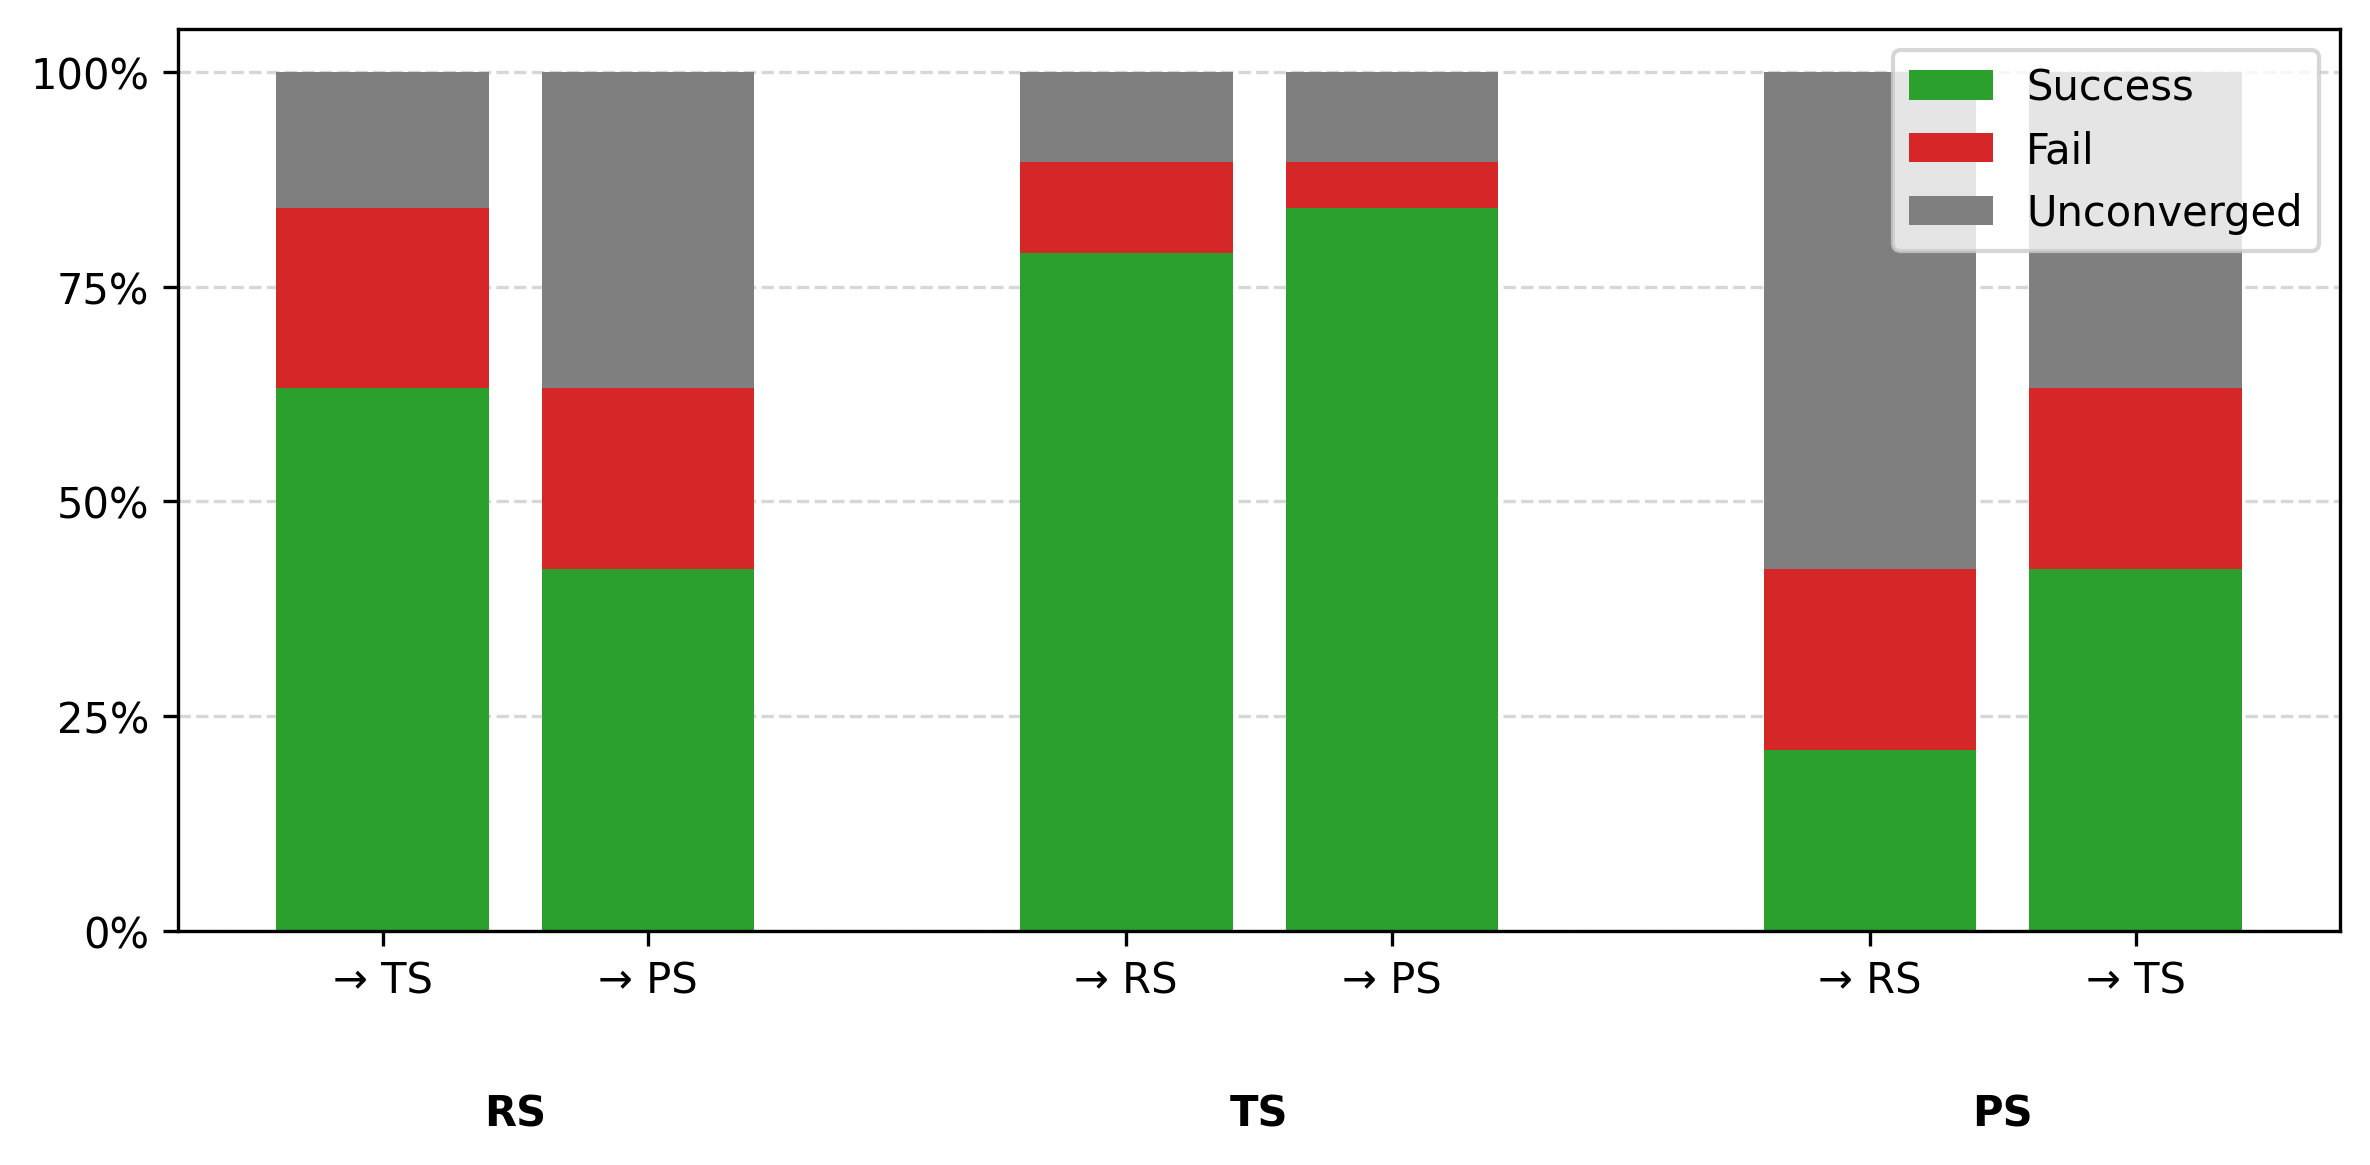

In [43]:
sections = {
    "RS": ["rs2ts", "rs2ps"],
    "TS": ["ts2rs", "ts2ps"],
    "PS": ["ps2rs", "ps2ts"],
}
dest_label = {
    "rs2ts": "→ TS",
    "rs2ps": "→ PS",
    "ts2rs": "→ RS",
    "ts2ps": "→ PS",
    "ps2rs": "→ RS",
    "ps2ts": "→ TS",
}

gap = 0.8
x_positions, x_labels, section_centers = [], [], {}
pos = 0.0
for sec, keys in sections.items():
    group_start = pos
    for k in keys:
        x_positions.append(pos)
        x_labels.append(dest_label[k])
        pos += 1.0
    section_centers[sec] = (group_start + pos - 1) / 2
    pos += gap

keys_ordered = [k for keys in sections.values() for k in keys]
successes = [trans_data[k]["success"] for k in keys_ordered]
fails = [trans_data[k]["fail"] for k in keys_ordered]
unconverged = [trans_data[k]["unconverged"] for k in keys_ordered]

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.bar(x_positions, successes, label="Success", color="tab:green")
ax.bar(x_positions, fails, label="Fail", color="tab:red", bottom=successes)
ax.bar(
    x_positions,
    unconverged,
    label="Unconverged",
    color="tab:gray",
    bottom=[s + f for s, f in zip(successes, fails)],
)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
# ax.set_ylabel("Count")
ax.set_yticks([0, 4.75, 9.5, 14.25, 19], ["0%", "25%", "50%", "75%", "100%"])
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend()

y_sec = -0.18
for sec, cx in section_centers.items():
    ax.text(
        cx,
        y_sec,
        sec,
        ha="center",
        va="top",
        fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

fig.tight_layout()
plt.show()

In [44]:
react_data = {
    "sub": {"success": 0, "fail": 0, "unconverged": 0},
    "oxygen": {"success": 0, "fail": 0, "unconverged": 0},
    "hydrogen": {"success": 0, "fail": 0, "unconverged": 0},
    "ad": {"success": 0, "fail": 0, "unconverged": 0},
}

category_data = {
    "rxn_01": "oxygen",
    "rxn_02": "hydrogen",
    "rxn_03": "hydrogen",
    "rxn_04": "hydrogen",
    "rxn_05": "ad",
    "rxn_06": "ad",
    "rxn_07": "ad",
    "rxn_08": "ad",
    "rxn_09": "ad",
    "rxn_10": "hydrogen",
    "rxn_11": "oxygen",
    "rxn_12": "oxygen",
    "rxn_13": "hydrogen",
    "rxn_14": "hydrogen",
    "rxn_15": "ad",
    "rxn_16": "sub",
    "rxn_17": "hydrogen",
    "rxn_18": "hydrogen",
    "rxn_19": "hydrogen",
}

for rxn, path in rxn_paths.items():
    rxn: str
    path: list[Atoms]
    rxn_name, run_type = rxn.split("-")
    ref = reference[rxn_name]

    category = category_data[rxn_name]

    if len(path) > 50:
        react_data[category]["unconverged"] += 1
        # print(rxn, "unconverged")
        continue
    elif run_type.endswith("2rs"):
        ref_conn = ref[0].info["connectivity"]
    elif run_type.endswith("2ts"):
        ref_conn = ref[1].info["connectivity"]
    elif run_type.endswith("2ps"):
        ref_conn = ref[2].info["connectivity"]

    ref_conn = [(int(row[0]), int(row[1]), float(row[2])) for row in ref_conn]
    bondorder = path[-1].get_array("bond-order")

    fail = False
    err = 0.0
    max_err = 0.0
    for i, j, val in ref_conn:
        # print(bondorder[i, j], val)
        # err += (bondorder[i, j] - val) ** 2
        # if abs(bondorder[i, j] - val) > 0.25:
        #     fail = True
        #     break
        if (berr := abs(bondorder[i, j] - val)) > max_err:
            max_err = berr
    if max_err < 0.5:
        react_data[category]["success"] += 1
    else:
        react_data[category]["fail"] += 1

print(react_data)

{'sub': {'success': 2, 'fail': 0, 'unconverged': 4}, 'oxygen': {'success': 8, 'fail': 4, 'unconverged': 6}, 'hydrogen': {'success': 25, 'fail': 11, 'unconverged': 18}, 'ad': {'success': 28, 'fail': 4, 'unconverged': 4}}


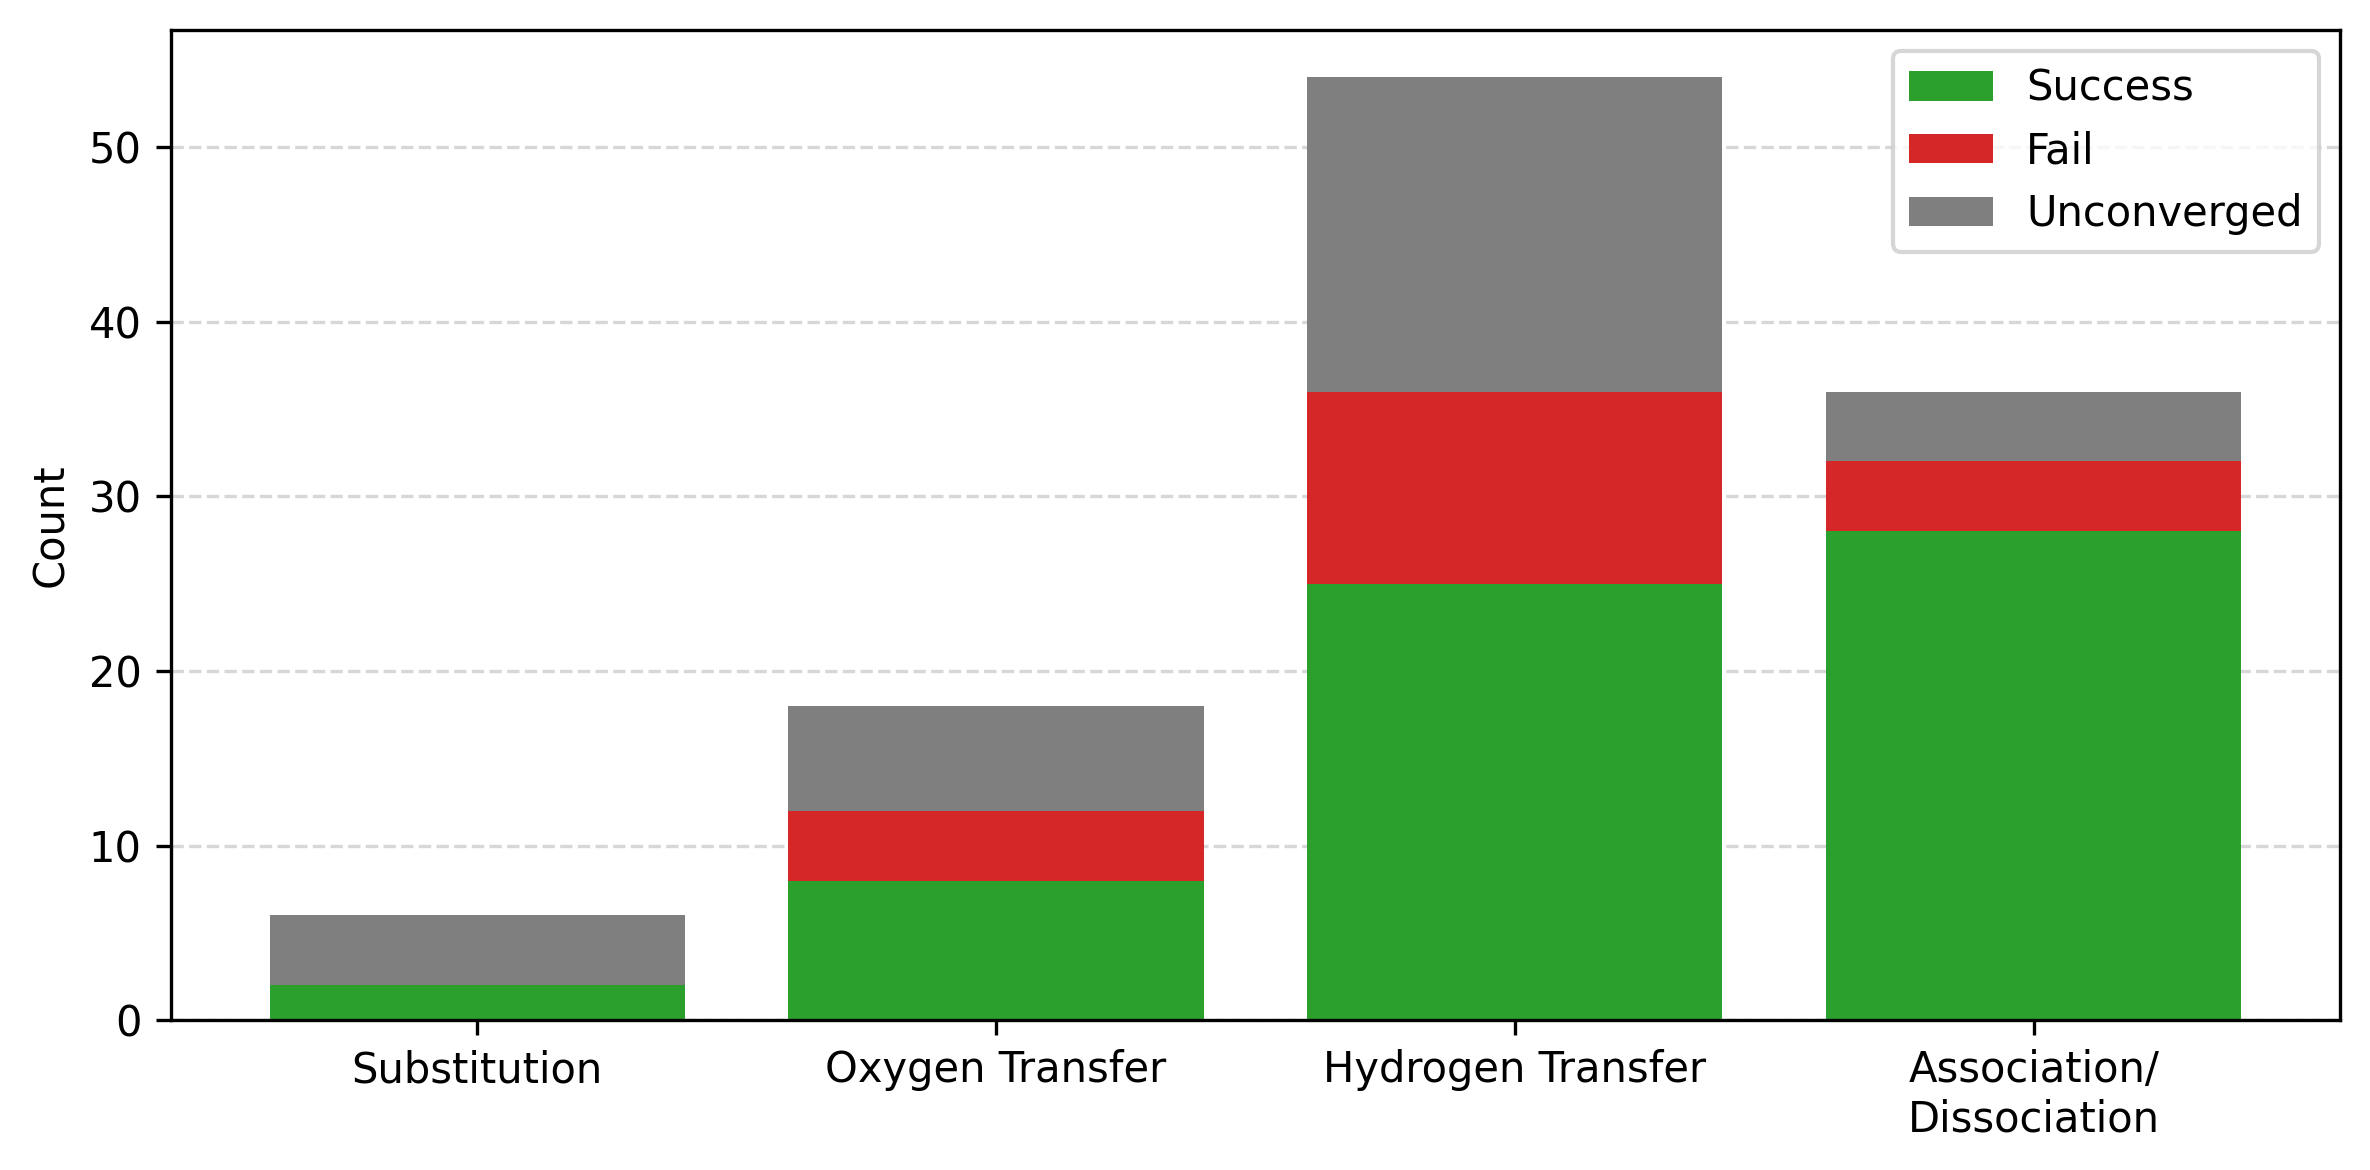

In [45]:
categories = ["sub", "oxygen", "hydrogen", "ad"]
cat_label = {
    "sub": "Substitution",
    "oxygen": "Oxygen Transfer",
    "hydrogen": "Hydrogen Transfer",
    "ad": "Association/\nDissociation",
}

x_positions = list(range(len(categories)))
successes = [react_data[c]["success"] for c in categories]
fails = [react_data[c]["fail"] for c in categories]
unconverged = [react_data[c]["unconverged"] for c in categories]

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
ax.bar(x_positions, successes, label="Success", color="tab:green")
ax.bar(x_positions, fails, label="Fail", color="tab:red", bottom=successes)
ax.bar(
    x_positions,
    unconverged,
    label="Unconverged",
    color="tab:gray",
    bottom=[s + f for s, f in zip(successes, fails)],
)

ax.set_xticks(x_positions)
ax.set_xticklabels([cat_label[c] for c in categories])
ax.set_ylabel("Count")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend()

fig.tight_layout()
plt.show()